# Multi Band Photometry

Define Global variables, methods
  

- mask fits data consists of integer. **Not bool**

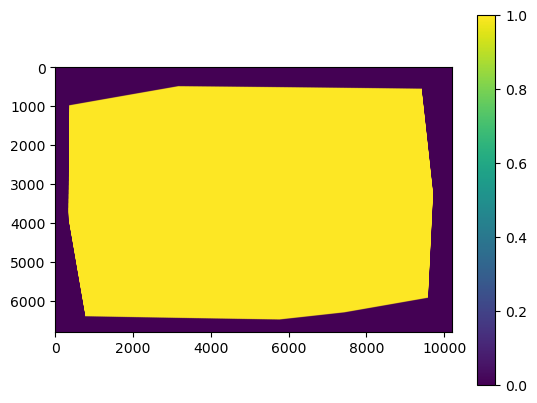

In [4]:
from astropy.table import Table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import (
    ImageNormalize,
    ZScaleInterval,
    PercentileInterval,
    AsinhStretch,
    LogStretch,
    SqrtStretch
)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import glob
from pathlib import Path


# Image preparation
COSMOS = 1
PROJECT_ROOT = Path("..")
DATA_ROOT = Path("../COSMOS_data")
BANDS_7DT = sorted({f'm{i}' for i in range(400, 900, 25)})
MASK_ROOT = DATA_ROOT / f"COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits"

valid_mask = fits.open(MASK_ROOT)[0].data
plt.imshow(valid_mask)
plt.colorbar()
plt.show()
valid_mask = valid_mask.astype(bool)

def get_image_path(cosmos, band, weight=False):
    image_folder = DATA_ROOT / f"COSMOS{cosmos}"

    suffix = "weight.fits" if weight else "com.fits"
    paths = list(image_folder.glob(f"*{band}*.{suffix}"))

    if len(paths) == 0:
        print(
            f"COSMOS {cosmos} - {band}: no matching {suffix} file."
        )
        return None

    if len(paths) > 1:
        raise RuntimeError(
            f"COSMOS {cosmos} - {band}: multiple matching {suffix} files."
        )

    return paths[0]

def get_catalog_path(cosmos, band):
    return PROJECT_ROOT / f'output/COSMOS{cosmos}/COSMOS_{cosmos}_cat_{band}.fits'

def plot_ImageAndDetectedSources(image, cat, center_point=None, length=None):
    if center_point is not None and length is not None:
        half = length / 2
        xmin = max(0, int(center_point[0] - half))
        xmax = min(image.shape[1], int(center_point[0] + half))
        ymin = max(0, int(center_point[1] - half))
        ymax = min(image.shape[0], int(center_point[1] + half))

        cat_plot = cat[
            (xmin <= cat['pixel_centroid_x'])
            & (cat['pixel_centroid_x'] < xmax)
            & (ymin <= cat['pixel_centroid_y'])
            & (cat['pixel_centroid_y'] < ymax)
        ]

        image_plot = image[ymin:ymax, xmin:xmax]

    else:
        ymin, xmin = 0, 0
        ymax, xmax = image.shape

        cat_plot = cat
        image_plot = image

    norm = ImageNormalize(
        image_plot,
        interval=ZScaleInterval()
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(
        image_plot,
        cmap='gray',
        norm=norm,
        origin='lower',
        extent=[xmin, xmax, ymin, ymax]
    )

    radius_pix = 5.94

    for x, y in zip(
        cat_plot['pixel_centroid_x'],
        cat_plot['pixel_centroid_y']
    ):
        ax.add_patch(
            Circle(
                (x, y),
                radius=radius_pix,
                fill=False,
                edgecolor='red',
                linewidth=1
            )
        )

    # Draw crosshair at center_point
    if center_point is not None:
        ax.axhline(y=center_point[1], color='cyan', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.axvline(x=center_point[0], color='cyan', linestyle='--', linewidth=0.8, alpha=0.7)

    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')

    plt.show()




## Data Basic Statistics

In [3]:
band_stats = {}

for band in BANDS_7DT:

    path = get_image_path(COSMOS, band)

    with fits.open(path, memmap=True) as hdul:

        data = hdul[0].data

        mean, median, std = sigma_clipped_stats(
            data,
            mask=~valid_mask,
            sigma=3,
            maxiters=5
        )

    band_stats[band] = {
        "mean": mean,
        "median": median,
        "std": std
    }

    print(
        f"{band:5s} "
        f"mean={mean:.5f}, "
        f"median={median:.5f}, "
        f"std={std:.5f}"
    )
    # plt.hist(
    # data[valid_mask],
    # bins=500,
    # histtype="step", 
    # label=f'COSMOS{COSMOS}-{band}, median={median:.5f}, std={std:.5f}'
    # )
    
    # plt.yscale("log")
    # plt.legend()
    # plt.savefig(
    #     PROJECT_ROOT / f"output/COSMOS1/image_histogram/background_hist_COSMOS{COSMOS}_{band}.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )
    # plt.show()


m400  mean=1.21984, median=1.19938, std=2.00648
m425  mean=1.13539, median=1.12365, std=1.66884
m450  mean=1.45253, median=1.42966, std=3.71906
m475  mean=1.09639, median=1.07940, std=1.94234
m500  mean=1.42112, median=1.38340, std=3.67069
m525  mean=1.14925, median=1.12732, std=2.11146
m550  mean=1.39629, median=1.35299, std=5.44565
m575  mean=1.15485, median=1.13458, std=2.23374
m600  mean=1.56946, median=1.53179, std=5.97872
m625  mean=1.37346, median=1.33688, std=2.66220
m650  mean=0.97639, median=0.92766, std=6.57758
m675  mean=1.00424, median=0.98352, std=1.88106
m700  mean=1.43601, median=1.40033, std=3.00385
m725  mean=1.07591, median=1.06063, std=1.79843
m750  mean=1.38192, median=1.36108, std=2.79094
m775  mean=0.97086, median=0.95952, std=1.72267
m800  mean=1.18859, median=1.15475, std=2.13939
m825  mean=1.01688, median=1.00585, std=1.32983
m850  mean=1.12227, median=1.11430, std=1.66557
m875  mean=1.03739, median=1.02100, std=1.51227


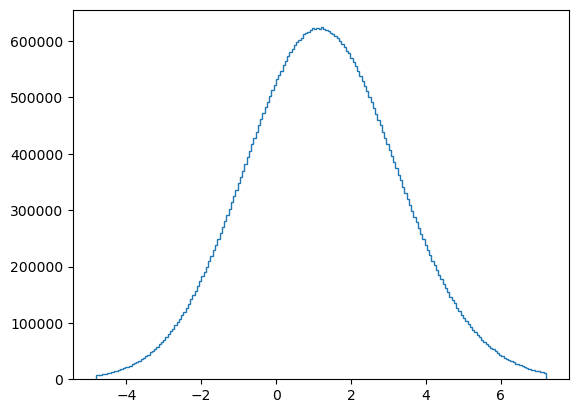

In [4]:
from astropy.stats import sigma_clip

for band in BANDS_7DT:
    path = get_image_path(COSMOS, band)
    with fits.open(path, memmap=True) as hdul:
        data = hdul[0].data
        clipped = sigma_clip(data[valid_mask], sigma=3, maxiters=5 )
        plt.hist(
        clipped.compressed(),
        bins=200,
        histtype="step"
    )

    plt.show()
    break

## Methods of Multiband CHI-MEAN Detection Image

Reference:  
*Dark Energy Survey Year 1 Results: The Photometric Data Set for Cosmology*  
(Drlica-Wagner et al. 2018)

### Background subtraction and noise normalization

For each band \(c\), the background-subtracted pixel value is defined as

$$
f_c(x,y)=I_c(x,y)-B_c
$$

where \(I_c(x,y)\) is the science image and \(B_c\) is the estimated background level.

The pixel noise is characterized by the background RMS:

$$
\sigma_c=\mathrm{std}(I_c)
$$

The normalized pixel value is therefore

$$
z_c(x,y)
=
\frac{f_c(x,y)}{\sigma_c}
=
\frac{I_c(x,y)-B_c}{\sigma_c}.
$$

Equivalently, defining the inverse-variance weight

$$
w_c=\frac{1}{\sigma_c^2},
$$

we obtain

$$
w_cf_c^2
=
\left(
\frac{f_c}{\sigma_c}
\right)^2
=
z_c^2.
$$


### Multiband chi detection image

The combined multiband detection statistic is constructed as

$$
\chi(x,y)
=
\sqrt{
\sum_{c=1}^{n}
w_cf_c(x,y)^2
}.
$$

Using the normalized pixel values, this can be written as

$$
\chi(x,y)
=
\sqrt{
\sum_{c=1}^{n}
z_c(x,y)^2
}.
$$

Here, \(n\) is the number of valid input bands.


### CHI-MEAN normalization

Assuming that the input noise in each band is Gaussian and independent, \(\chi(x,y)\) follows a chi distribution.

The mean of the chi distribution is

$$
\mu
=
\sqrt{2}
\frac{
\Gamma((n+1)/2)
}{
\Gamma(n/2)
}.
$$

The CHI-MEAN detection image is defined as

$$
\mathrm{CHI\text{-}MEAN}(x,y)
=
\frac{
\chi(x,y)-\mu
}{
\sqrt{n-\mu^2}
}.
$$

This normalization removes the dependence of the background statistics on the number of input bands and produces a detection image with approximately zero-centered background statistics.


### Prototype implementation assumptions

For the prototype detection map, the following assumptions are adopted:

- The background level is estimated globally for each band.
- The RMS noise is estimated using sigma-clipped statistics.
- Spatial variations of the background and RMS are ignored.

Therefore, for each band:

$$
B_c=\mathrm{median}(I_c)
$$

and

$$
\sigma_c=\mathrm{std}_{\mathrm{clipped}}(I_c)
$$

are adopted.


### Final prototype CHI-MEAN detection map

The final detection image is therefore constructed as

$$
D(x,y)
=
\frac{
\sqrt{
\sum_c
\left(
\frac{
I_c(x,y)-B_c
}{
\sigma_c
}
\right)^2
}
-\mu
}{
\sqrt{n-\mu^2}
}.
$$

## Actual code implementation
### Sample Image normalization

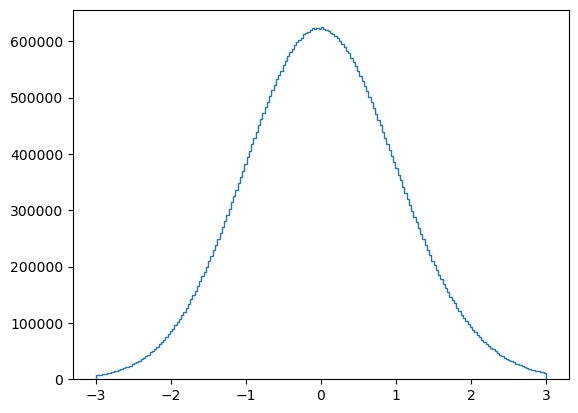

In [5]:
band = 'm400'
with fits.open(get_image_path(COSMOS, band), memmap=True) as hdul :
    image = hdul[0].data 
    header = hdul[0].header 
    B = band_stats[band]['median']
    sigma = band_stats[band]['std']
    
    z = (image - B) / sigma
    
image_shape = image.shape

clipped = sigma_clip(z[valid_mask], sigma=3, maxiters=5 )
plt.hist(
    clipped.compressed(),
    bins=200,
    histtype="step"
)
plt.show()


### Make chi2 image

n_band : 20


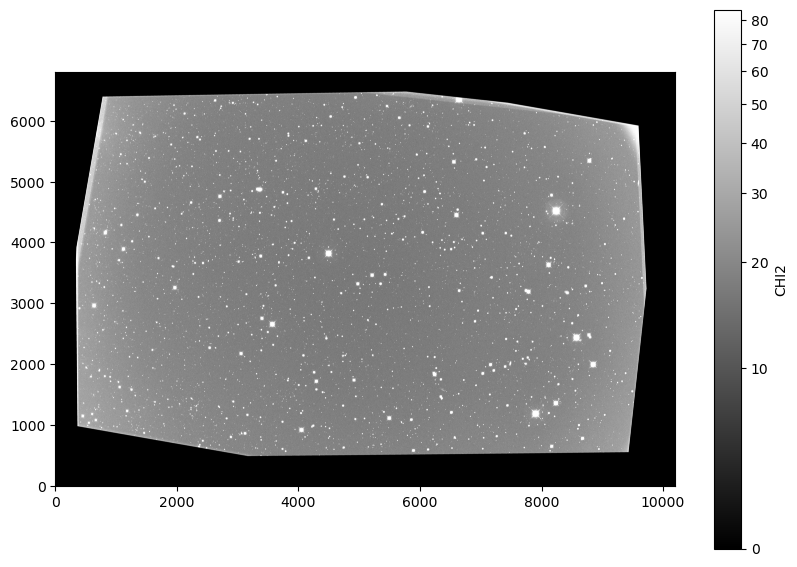

In [6]:
chi2 = np.zeros(image_shape, dtype=np.float32)
n_band = 0

for band in BANDS_7DT :
    image_path = get_image_path(COSMOS, band)
    if image_path is None : continue
    n_band += 1
    
    with fits.open(image_path, memmap=True) as hdul :
        image = hdul[0].data 
        header = hdul[0].header 
        
        B = band_stats[band]['median']
        sigma = band_stats[band]['std']
        
        z = (image - B) / sigma
        z[~valid_mask] = 0
        
        chi2 += z.astype(np.float32)**2


print(f'n_band : {n_band}')

# plot chi2 image
norm = ImageNormalize(
    chi2,
    interval=ZScaleInterval(),
    stretch=AsinhStretch()
)

plt.figure(figsize=(10,7))

plt.imshow(
    chi2,
    origin="lower",
    cmap="gray",
    norm=norm
)

plt.colorbar(
    label="CHI2"
)

plt.show()

### Chi-mean normalization

mean : 0.027925143
median : -0.023813143
std : 1.0722079


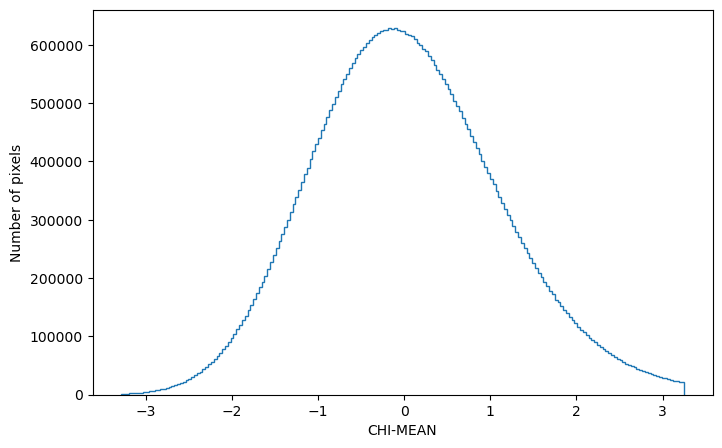

In [ ]:
chi = np.sqrt(chi2)

from scipy.special import gammaln

mu = (
    np.sqrt(2) 
    * 
    np.exp(
        gammaln((n_band+1)/2) -gammaln(n_band/2)
    )
)

chi_mean = (chi - mu) / np.sqrt( n_band - mu**2)
chi_mean[~valid_mask] = np.nan

with fits.open(get_image_path(COSMOS, 'm400')) as hdul :
    header = hdul[0].header

fits.writeto(
    PROJECT_ROOT / f'COSMOS_data/COSMOS{COSMOS}/COSMOS{COSMOS}_detectionimage.fits', 
    chi_mean, 
    header=header, 
    overwrite=True
)

values = chi_mean[np.isfinite(chi_mean)]

plt.figure(figsize=(8,5))

values = sigma_clip(
    chi_mean[valid_mask],
    sigma=3
).compressed()

print("mean :", np.mean(values))
print("median :", np.median(values))
print("std :", np.std(values))

plt.hist(
    values,
    bins=200,
    histtype="step"
)

plt.xlabel("CHI-MEAN")
plt.ylabel("Number of pixels")

plt.show()


### Photometry with SE++

```commandline
sourcextractor++ \
    --detection-image detect.fits \
    --python-config-file aperture.py \
    --output-catalog-filename photometry.fits \
    --output-properties AperturePhotometry
```



In [ ]:
import subprocess
from pathlib import Path

APER_3ARCSEC = 5.94059406
DETECTION_THRESHOLD = 3
DETECTION_MINIMUM_AREA = 3
THREAD_COUNT = 1

detection_image_path = PROJECT_ROOT / f'output/COSMOS{COSMOS}/COSMOS{COSMOS}_detectionimage.fits'
config_path = PROJECT_ROOT / 'seppconfig/multiphotconfig.config'
pyconfig_path = PROJECT_ROOT / 'seppconfig/multiphotconfig.py'
cat_name = f'cat_cosmos{COSMOS}.fits'

command = [
    "sourcextractor++",
    "--config-file", 
    f"{config_path}"
]

subprocess.run(
    command,
    check=True
)

2026-08-24T13:14:44KST Config  INFO : Using the default segmentation (3x3) filter.
2026-08-24T13:14:46KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(../output/COSMOS1/COSMOS1_detectionimage.fits)) with 0.0 weight image masked pixels; median: -0.12361 rms: 0.957752!
2026-08-24T13:14:48KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.com.fits)) with 0.0 weight image masked pixels; median: 1.11128 rms: 1.97927!
2026-08-24T13:14:50KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240504_213152_m425_12480.com.fits)) with 0.0 weight image masked pixels; median: 1.08187 rms: 1.63233!
2026-08-24T13:14:52KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7

CalledProcessError: Command '['sourcextractor++', '--detection-image', '../output/COSMOS1/COSMOS1_detectionimage.fits', '--python-config-file', '../multiphotconfig.py', '--output-catalog-filename', 'cat_cosmos1.fits', '--output-properties', 'PixelCentroid']' died with <Signals.SIGSEGV: 11>.

Problem solving code : NONE detection in detection image

In [ ]:
# Zero Point Check

ZP_3_list = {}

for band in BANDS_7DT : 
    image_path = get_image_path(COSMOS, band)
    if image_path is not None : 
        with fits.open(image_path, memmap=True) as hdul :
            image = hdul[0].data 
            header = hdul[0].header 

        ZP_3_list[band] = header["ZP_3"]
    else : 
        ZP_3_list[band] = None

print(ZP_3_list)



{'m400': 25.537, 'm425': 26.064, 'm450': 26.183, 'm475': 26.131, 'm500': 26.461, 'm525': 26.287, 'm550': 26.093, 'm575': 25.931, 'm600': 26.021, 'm625': 25.678, 'm650': 25.766, 'm675': 25.578, 'm700': 25.267, 'm725': 24.945, 'm750': 24.808, 'm775': 24.294, 'm800': 24.049, 'm825': 23.52, 'm850': 23.519, 'm875': 23.013}


### Result Check

In [1]:
from astropy.io import fits
import numpy as np

fn = "/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage.fits"

d = fits.getdata(fn)

finite = np.isfinite(d)
x = d[finite]

print("shape  :", d.shape)
print("min    :", np.min(x))
print("max    :", np.max(x))
print("mean   :", np.mean(x))
print("median :", np.median(x))
print("std    :", np.std(x))

for q in [90, 95, 99, 99.9, 99.99, 99.999]:
    print(f"{q:7.3f}% :", np.percentile(x, q))

for t in [1, 2, 2.5, 3, 3.2, 3.5, 4, 5]:
    print(f"N(pixel > {t:3.1f}) =", np.sum(x > t))
    


shape  : (6800, 10200)
min    : -4.455905
max    : 193085.11
mean   : 4.500402
median : 0.014523669
std    : 429.15955
 90.000% : 1.6540347337722778
 95.000% : 2.3448787689208928
 99.000% : 10.637356033325432
 99.900% : 375.5944501647955
 99.990% : 6477.710340169673
 99.999% : 64071.736997818865
N(pixel > 1.0) = 10800103
N(pixel > 2.0) = 3657830
N(pixel > 2.5) = 2318399
N(pixel > 3.0) = 1659171
N(pixel > 3.2) = 1501864
N(pixel > 3.5) = 1332180
N(pixel > 4.0) = 1153321
N(pixel > 5.0) = 957251


detection image - no detection prbm  

Solution : make no nan image

In [1]:
from astropy.io import fits
import numpy as np

fn = "/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage.fits"

with fits.open(fn) as hdul:
    data = hdul[0].data.copy()
    header = hdul[0].header
    
print("NaN:", np.isnan(data).sum())
print("finite:", np.isfinite(data).sum())

data[~np.isfinite(data)] = 0.0

fits.writeto(
    "/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage_nonan.fits",
    data,
    header=header,
    overwrite=True
)


NaN: 16575980
finite: 52784020


In [6]:
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

det = fits.getdata(
    "/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage_nonan.fits"
)

meas = fits.getdata(
    "/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240423_002413_m650_3960.com.fits"
)

print("detection :", det.shape)
print("measurement:", meas.shape)

det_path = "/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage_nonan.fits"
meas_path = "/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240423_002413_m650_3960.com.fits"

with fits.open(det_path) as h:
    w_det = WCS(h[0].header)

with fits.open(meas_path) as h:
    w_meas = WCS(h[0].header)

print(w_det)
print(w_meas)

m = fits.getdata(
    "/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240423_002413_m650_3960.com.fits"
)

print("shape :", m.shape)
print("NaN   :", np.isnan(m).sum())
print("Inf   :", np.isinf(m).sum())
print("finite:", np.isfinite(m).sum())



detection : (6800, 10200)
measurement: (6800, 10200)
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 149.8 1.95
CRPIX : 5100.5 3400.5
CD1_1 CD1_2  : -0.0001402777777778 0.0
CD2_1 CD2_2  : 0.0 0.0001402777777778
NAXIS : 10200  6800
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 149.8 1.95
CRPIX : 5100.5 3400.5
CD1_1 CD1_2  : -0.0001402777777778 0.0
CD2_1 CD2_2  : 0.0 0.0001402777777778
NAXIS : 10200  6800
shape : (6800, 10200)
NaN   : 0
Inf   : 0


finite: 69360000


### Catalog check

In [28]:
import numpy as np
from astropy.table import Table

cat = Table.read(
    '/Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/SE++/test_catalog.fits'
)

flags = cat['aper3_flags']

print("flags shape:", flags.shape)

# 각 source에서 flag == 0인 값이 하나라도 있으면 유지
mask = np.any(flags == 0, axis=(1, 2))

print("mask shape:", mask.shape)

cat = cat[mask]

print(f'Number of sources : {len(cat)}')
print("Catalog sample")
cat[:20].pprint(max_width=-1)

print("aper3_flags")
print(cat['aper3_mag'][0])

flags shape: (21687, 20, 1)
mask shape: (21687,)
Number of sources : 10777
Catalog sample
source_id detection_id  pixel_centroid_x  pixel_centroid_y  world_centroid_alpha world_centroid_delta         aper3_flux            aper3_flux_err            aper3_mag              aper3_mag_err       aper3_flags
                              pix               pix                 deg                  deg                      ct                      ct                     mag                      mag                       
--------- ------------ ----------------- ------------------ -------------------- -------------------- ------------------------- ---------------------- ------------------------ ------------------------ -----------
        3            6 3296.080322265625              494.0   150.05320365403398     1.54227446772669     8.584251 .. 4.7821717 10.322042 .. 7.6386333  -2.334256 .. -1.6990628   1.3054885 .. 1.7342045      0 .. 0
        7           12 3234.992431640625  494.178924560546

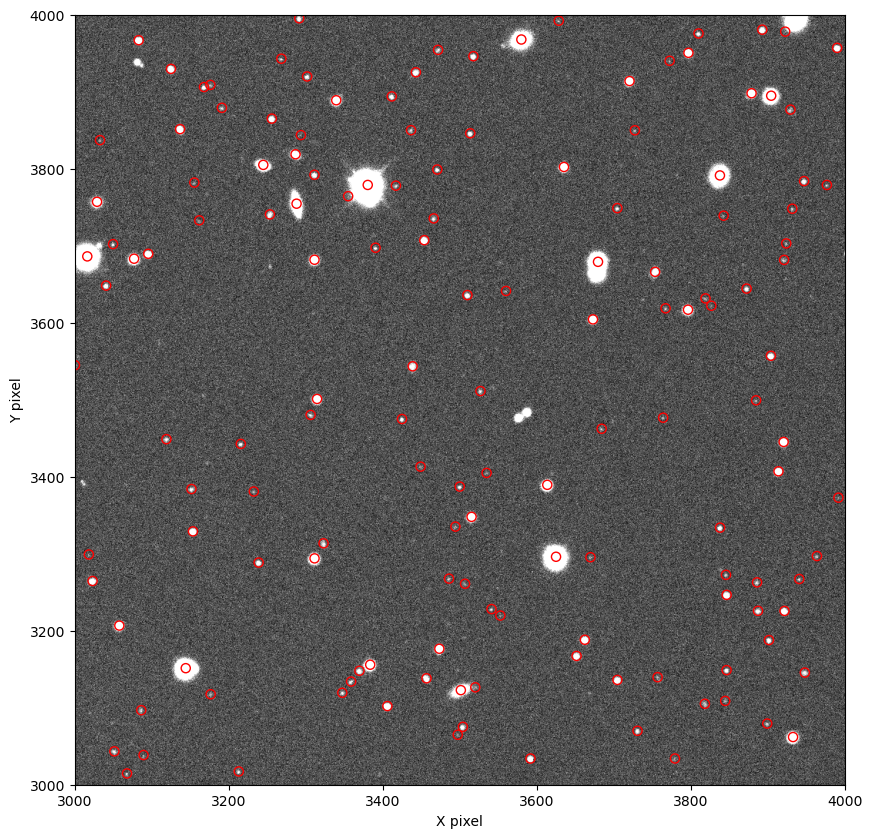

In [12]:
# detected sources
det = fits.getdata("/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage_nonan.fits")
plot_ImageAndDetectedSources(det, cat, center_point=[3500, 3500], length=1000)

### Make test SED

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

def save_SED(col, available_bands, save_dir) : 
    # template of available bands : m400 >> 4000 Å
    x = np.array([int(band[1:]) * 10 for band in available_bands])
    y = np.asarray(col['aper3_mag']).squeeze()
    good = (y!=0)
    
    # print(f'y={y}')
    # print(f'y length = {len(y)}')
    # print(f'x length = {len(x)}')
    
    y_err = np.abs(np.asarray(col['aper3_mag_err']).squeeze())
    
    plt.figure()
    plt.errorbar(x[good], y[good], yerr=y_err[good], fmt='o', capsize=3)
    plt.xlabel('Wavelength [Å]')
    plt.ylabel('Magnitude')
    
    # magnitude는 밝을수록 숫자가 작으므로 뒤집는 것이 보통 자연스러움
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.savefig(save_dir / f"{col['source_id']}.png")
    plt.close()

save_dir = PROJECT_ROOT / f'output/COSMOS{COSMOS}/multibandphot/sed'
save_dir.mkdir(parents=True, exist_ok=True)

bands = [f'm{i}' for i in range(400, 900, 25)]

for i , col in enumerate(tqdm(cat)) : 
    save_SED(col, bands, save_dir)
    

100%|██████████| 10777/10777 [05:09<00:00, 34.87it/s]
